In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Analytics Notebook Started Successfully")

Analytics Notebook Started Successfully


In [2]:
rcb_2025 = pd.read_csv(
    "../data/processed/rcb_2025_matches.csv"
)

rcb_2025.head()

,date,opponent,venue,rcb_score,opponent_score,result
0,2025-03-22,KKR,Kolkata,177,174,Win
1,2025-03-28,CSK,Chennai,196,146,Win
2,2025-04-02,GT,Bengaluru,169,170,Loss
3,2025-04-07,MI,Mumbai,221,209,Win
4,2025-04-10,DC,Bengaluru,163,169,Loss


In [3]:
rcb_2026 = pd.read_csv(
    "../data/processed/rcb_2026_matches.csv"
)

rcb_2026.head()

,date,opponent,venue,rcb_score,opponent_score,result
0,2026-03-28,SRH,Bengaluru,203,201,Win
1,2026-04-05,CSK,Bengaluru,250,207,Win
2,2026-04-10,RR,Guwahati,201,202,Loss
3,2026-04-12,MI,Mumbai,240,222,Win
4,2026-04-15,LSG,Bengaluru,149,146,Win


In [4]:
rcb_2025["season"] = 2025

In [5]:
rcb_2026["season"] = 2026

In [6]:
combined_rcb = pd.concat([
    rcb_2025,
    rcb_2026
])

combined_rcb

,date,opponent,venue,rcb_score,opponent_score,result,season
0,2025-03-22,KKR,Kolkata,177,174,Win,2025
1,2025-03-28,CSK,Chennai,196,146,Win,2025
2,2025-04-02,GT,Bengaluru,169,170,Loss,2025
3,2025-04-07,MI,Mumbai,221,209,Win,2025
4,2025-04-10,DC,Bengaluru,163,169,Loss,2025
5,2025-04-13,RR,Jaipur,175,173,Win,2025
6,2025-04-18,PBKS,Bengaluru,95,98,Loss,2025
7,2025-04-20,PBKS,Mullanpur,159,157,Win,2025
8,2025-04-24,RR,Bengaluru,205,194,Win,2025
9,2025-04-27,DC,Delhi,165,162,Win,2025


In [8]:
combined_rcb.to_csv(
    "../data/processed/combined_rcb_dataset.csv",
    index=False
)

print("Combined Dataset Saved Successfully")

Combined Dataset Saved Successfully


In [9]:
wins = combined_rcb[
    combined_rcb["result"] == "Win"
].shape[0]

total_matches = combined_rcb.shape[0]

win_percentage = (wins / total_matches) * 100

print("RCB Win Percentage:", win_percentage)

RCB Win Percentage: 70.0


In [10]:
season_wins = combined_rcb.groupby(
    "season"
)["result"].value_counts()

season_wins

season  result
2025    Win       11
        Loss       4
2026    Win       10
        Loss       5
Name: count, dtype: int64

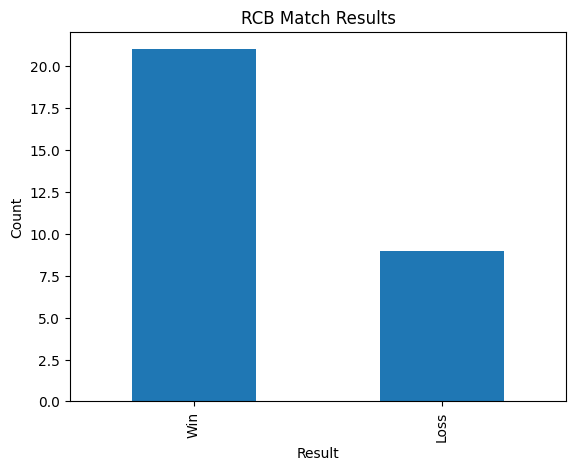

In [11]:
combined_rcb["result"].value_counts().plot(
    kind="bar"
)

plt.title("RCB Match Results")
plt.xlabel("Result")
plt.ylabel("Count")

plt.show()

In [12]:
highest_scores = combined_rcb.sort_values(
    by="rcb_score",
    ascending=False
)

highest_scores.head()

,date,opponent,venue,rcb_score,opponent_score,result,season
14,2026-05-26,GT,Dharamsala,254,162,Win,2026
1,2026-04-05,CSK,Bengaluru,250,207,Win,2026
3,2026-04-12,MI,Mumbai,240,222,Win,2026
12,2025-05-27,LSG,Lucknow,230,227,Win,2025
12,2026-05-17,PBKS,Dharamsala,222,199,Win,2026


In [13]:
season_consistency = combined_rcb.groupby(
    "season"
)["result"].apply(
    lambda x: (x == "Win").mean() * 100
)

print(season_consistency)

season
2025    73.333333
2026    66.666667
Name: result, dtype: float64


In [14]:
venue_performance = combined_rcb.groupby(
    "venue"
)["result"].value_counts()

venue_performance

venue       result
Ahmedabad   Win       1
            Loss      1
Bengaluru   Win       6
            Loss      4
Chennai     Win       1
Delhi       Win       2
Dharamsala  Win       2
Guwahati    Loss      1
Hyderabad   Loss      1
Jaipur      Win       1
Kolkata     Win       1
Lucknow     Loss      2
            Win       1
Mullanpur   Win       2
Mumbai      Win       2
Raipur      Win       2
Name: count, dtype: int64

In [15]:
combined_rcb["match_type"] = np.where(
    combined_rcb["venue"] == "Bengaluru",
    "Home",
    "Away"
)

combined_rcb

,date,opponent,venue,rcb_score,opponent_score,result,season,match_type
0,2025-03-22,KKR,Kolkata,177,174,Win,2025,Away
1,2025-03-28,CSK,Chennai,196,146,Win,2025,Away
2,2025-04-02,GT,Bengaluru,169,170,Loss,2025,Home
3,2025-04-07,MI,Mumbai,221,209,Win,2025,Away
4,2025-04-10,DC,Bengaluru,163,169,Loss,2025,Home
5,2025-04-13,RR,Jaipur,175,173,Win,2025,Away
6,2025-04-18,PBKS,Bengaluru,95,98,Loss,2025,Home
7,2025-04-20,PBKS,Mullanpur,159,157,Win,2025,Away
8,2025-04-24,RR,Bengaluru,205,194,Win,2025,Home
9,2025-04-27,DC,Delhi,165,162,Win,2025,Away


In [16]:
home_away_performance = combined_rcb.groupby(
    "match_type"
)["result"].value_counts()

home_away_performance

match_type  result
Away        Win       15
            Loss       5
Home        Win        6
            Loss       4
Name: count, dtype: int64

In [17]:
average_runs = combined_rcb.groupby(
    "season"
)["rcb_score"].mean()

print(average_runs)

season
2025    176.866667
2026    193.066667
Name: rcb_score, dtype: float64


In [18]:
combined_rcb["margin"] = abs(
    combined_rcb["rcb_score"] -
    combined_rcb["opponent_score"]
)

combined_rcb.head()

,date,opponent,venue,rcb_score,opponent_score,result,season,match_type,margin
0,2025-03-22,KKR,Kolkata,177,174,Win,2025,Away,3
1,2025-03-28,CSK,Chennai,196,146,Win,2025,Away,50
2,2025-04-02,GT,Bengaluru,169,170,Loss,2025,Home,1
3,2025-04-07,MI,Mumbai,221,209,Win,2025,Away,12
4,2025-04-10,DC,Bengaluru,163,169,Loss,2025,Home,6


In [19]:
highest_margin = combined_rcb.sort_values(
    by="margin",
    ascending=False
)

highest_margin.head()

,date,opponent,venue,rcb_score,opponent_score,result,season,match_type,margin
14,2026-05-26,GT,Dharamsala,254,162,Win,2026,Away,92
13,2026-05-22,SRH,Hyderabad,200,255,Loss,2026,Away,55
1,2025-03-28,CSK,Chennai,196,146,Win,2025,Away,50
1,2026-04-05,CSK,Bengaluru,250,207,Win,2026,Home,43
11,2025-05-23,SRH,Lucknow,189,231,Loss,2025,Away,42


In [20]:
opponent_performance = combined_rcb.groupby(
    "opponent"
)["result"].value_counts()

opponent_performance

opponent  result
CSK       Win       3
DC        Loss      2
          Win       2
GT        Loss      2
          Win       2
KKR       Win       2
LSG       Win       2
          Loss      1
MI        Win       3
PBKS      Win       4
          Loss      1
RR        Win       2
          Loss      1
SRH       Loss      2
          Win       1
Name: count, dtype: int64

In [21]:
season_win_percentage = combined_rcb.groupby(
    "season"
)["result"].apply(
    lambda x: (x == "Win").mean() * 100
)

print(season_win_percentage)

season
2025    73.333333
2026    66.666667
Name: result, dtype: float64


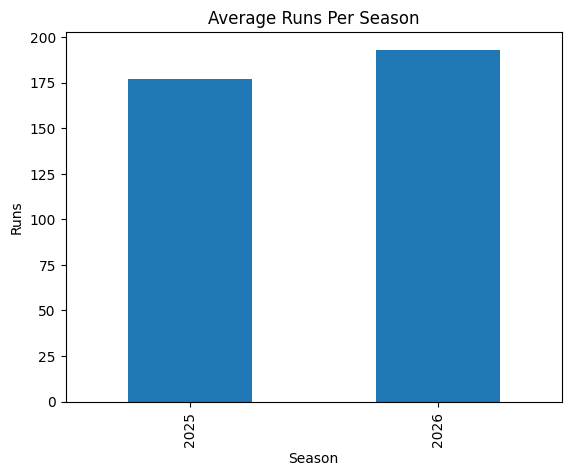

In [22]:
average_runs.plot(
    kind="bar"
)

plt.title("Average Runs Per Season")
plt.xlabel("Season")
plt.ylabel("Runs")

plt.show()

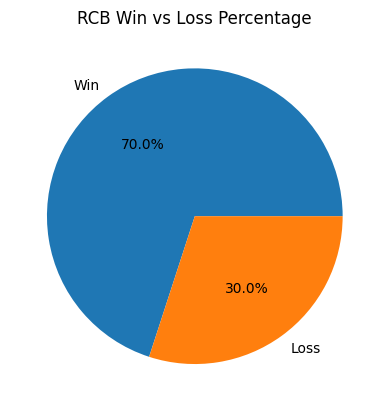

In [23]:
combined_rcb["result"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("RCB Win vs Loss Percentage")

plt.ylabel("")

plt.show()

In [24]:
top_scores = combined_rcb.sort_values(
    by="rcb_score",
    ascending=False
).head(5)

print(top_scores)

          date opponent       venue  rcb_score  opponent_score result  season  \
14  2026-05-26       GT  Dharamsala        254             162    Win    2026   
1   2026-04-05      CSK   Bengaluru        250             207    Win    2026   
3   2026-04-12       MI      Mumbai        240             222    Win    2026   
12  2025-05-27      LSG     Lucknow        230             227    Win    2025   
12  2026-05-17     PBKS  Dharamsala        222             199    Win    2026   

   match_type  margin  
14       Away      92  
1        Home      43  
3        Away      18  
12       Away       3  
12       Away      23  


In [25]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

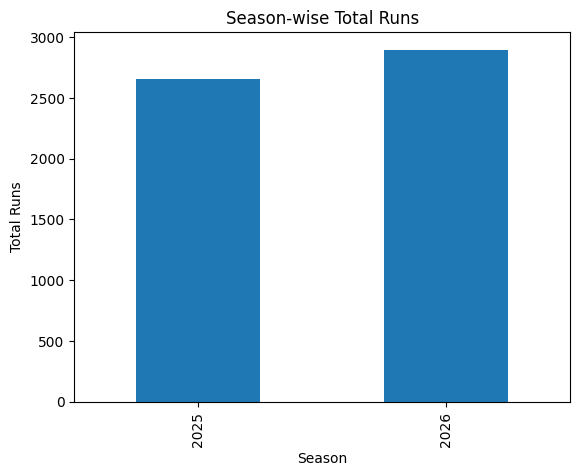

In [26]:
season_runs = combined_rcb.groupby(
    "season"
)["rcb_score"].sum()

season_runs.plot(
    kind="bar"
)

plt.title("Season-wise Total Runs")
plt.xlabel("Season")
plt.ylabel("Total Runs")

plt.show()

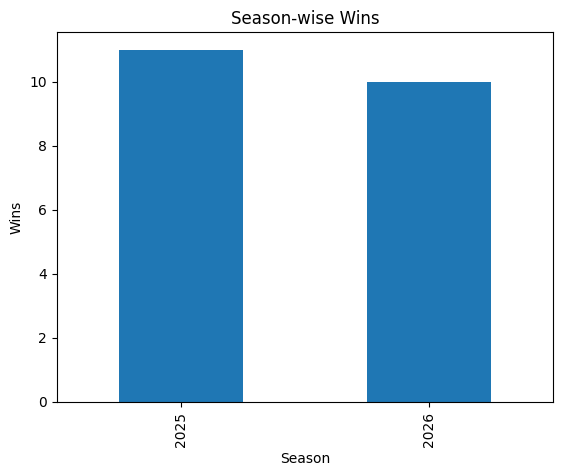

In [27]:
season_wins = combined_rcb[
    combined_rcb["result"] == "Win"
].groupby("season").size()

season_wins.plot(
    kind="bar"
)

plt.title("Season-wise Wins")
plt.xlabel("Season")
plt.ylabel("Wins")

plt.show()

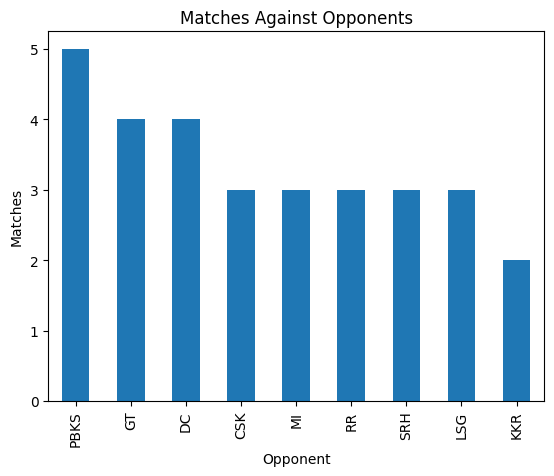

In [28]:
opponent_matches = combined_rcb[
    "opponent"
].value_counts()

opponent_matches.plot(
    kind="bar"
)

plt.title("Matches Against Opponents")
plt.xlabel("Opponent")
plt.ylabel("Matches")

plt.show()

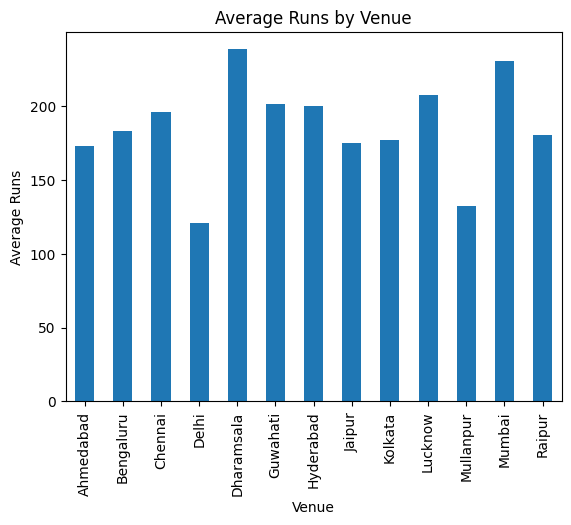

In [29]:
venue_runs = combined_rcb.groupby(
    "venue"
)["rcb_score"].mean()

venue_runs.plot(
    kind="bar"
)

plt.title("Average Runs by Venue")
plt.xlabel("Venue")
plt.ylabel("Average Runs")

plt.show()

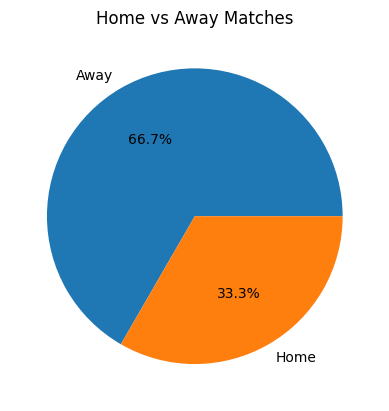

In [30]:
combined_rcb["match_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Home vs Away Matches")

plt.ylabel("")

plt.show()

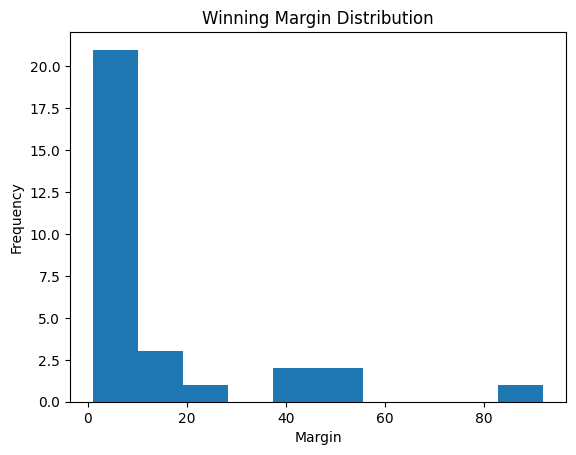

In [31]:
combined_rcb["margin"].plot(
    kind="hist",
    bins=10
)

plt.title("Winning Margin Distribution")
plt.xlabel("Margin")
plt.ylabel("Frequency")

plt.show()

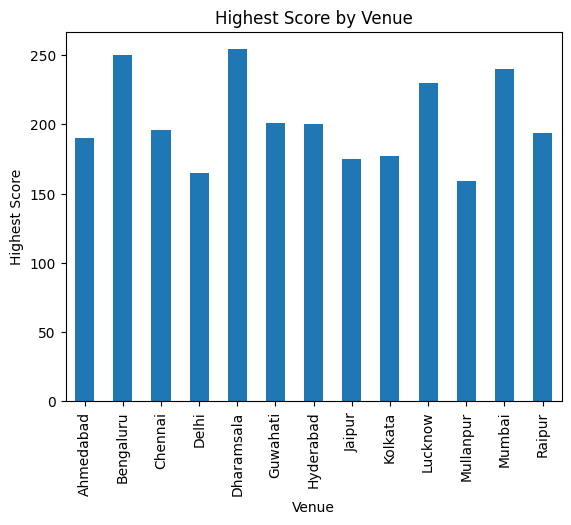

In [32]:
top_venues = combined_rcb.groupby(
    "venue"
)["rcb_score"].max()

top_venues.plot(
    kind="bar"
)

plt.title("Highest Score by Venue")
plt.xlabel("Venue")
plt.ylabel("Highest Score")

plt.show()

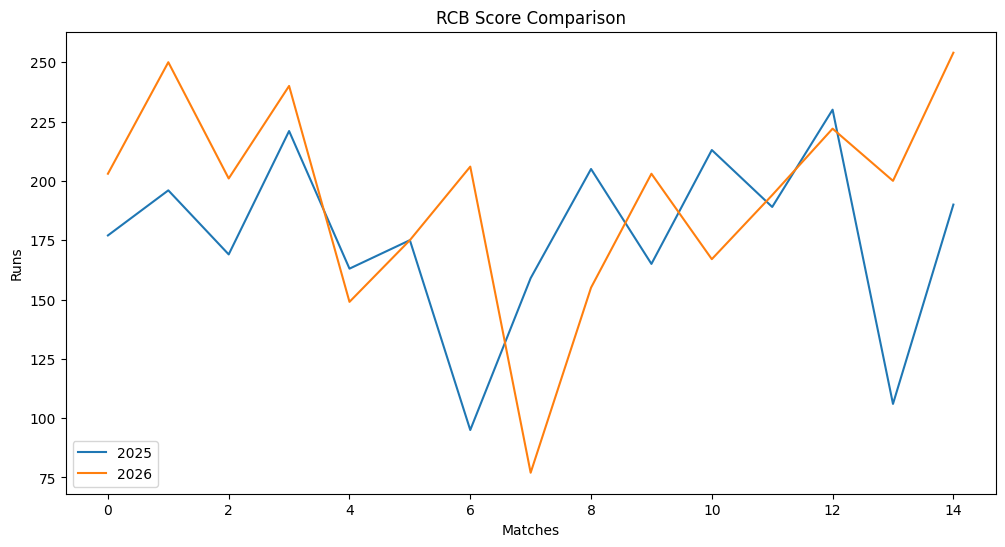

In [33]:
season_2025 = combined_rcb[
    combined_rcb["season"] == 2025
]

season_2026 = combined_rcb[
    combined_rcb["season"] == 2026
]

plt.figure(figsize=(12,6))

plt.plot(
    season_2025["rcb_score"].values,
    label="2025"
)

plt.plot(
    season_2026["rcb_score"].values,
    label="2026"
)

plt.title("RCB Score Comparison")
plt.xlabel("Matches")
plt.ylabel("Runs")

plt.legend()

plt.show()

In [34]:
dashboard_summary = pd.DataFrame({

    "Metric": [
        "Total Matches",
        "Total Wins",
        "Highest Score",
        "Average Runs"
    ],

    "Value": [
        combined_rcb.shape[0],

        combined_rcb[
            combined_rcb["result"] == "Win"
        ].shape[0],

        combined_rcb["rcb_score"].max(),

        combined_rcb["rcb_score"].mean()
    ]
})

dashboard_summary

,Metric,Value
0,Total Matches,30.000000
1,Total Wins,21.000000
2,Highest Score,254.000000
3,Average Runs,184.966667
